In [1]:
## Imports and Initialization -------------------------------------------------|
print("Importing dependencies... ")

import sys
import os, os.path
sys.path.append(os.path.abspath(".."))  # Adjust path to package root
import math

# third party
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt

# internal
import abstraction
import algorithm
from astropy.io import fits
from utility import IndexSchema, get_fits_paths, load_image_data
from examples.fits_to_mp4 import fits_to_mp4, data_to_mp4
from reference_method import ExternalRefs, RollingWindow

## Fetch Data ------------------------------------------------------------------

files_dir = os.path.abspath(os.path.join(".", "media", "large"))
files = get_fits_paths(files_dir)
files = files
# print("\n".join(files))
print(f"{len(files)} files found")

# variable paths for destretch results

kernel_sizes: np.ndarray[np.int64] = np.array([128, 64])
destretched_dir = os.path.join(files_dir, "destretched")
out_off_dir = os.path.join(files_dir, "off")
out_sum_dir = os.path.join(files_dir, "sum")
out_rolling_sum_dir = os.path.join(files_dir, "rolling_sum")
out_off_control_dir = os.path.join(files_dir, "off_control")
out_dir = os.path.join(files_dir, "destretched")
out_dir_control = os.path.join(files_dir, "destretched_control")
out_off_final_dir = os.path.join(files_dir, "off_final")

original_files = files.copy()
traditional_files = get_fits_paths(os.path.join(files_dir, "destretched_bad"))
destretched_files = get_fits_paths(destretched_dir)
off_files = get_fits_paths(out_off_dir)
off_final_files = get_fits_paths(out_off_final_dir)
sum_files = get_fits_paths(out_sum_dir)
sum_avg_files = get_fits_paths(out_rolling_sum_dir)
rolling_sum_files = get_fits_paths(out_rolling_sum_dir)
file_count = len(off_files)


Importing dependencies... 
1400 files found


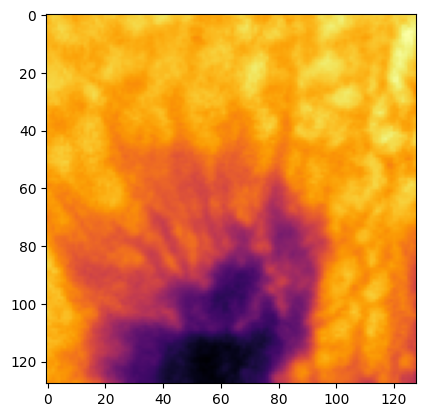

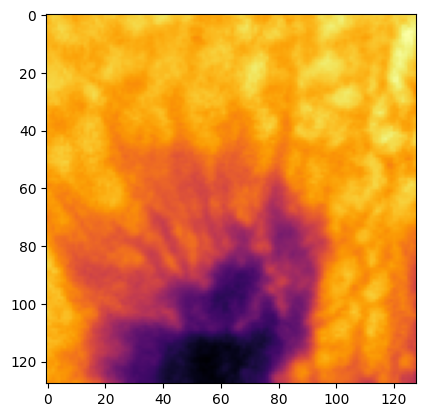

In [2]:
# define shubwindow and shifted subwindow

xy = (400, 400)
delta = 0
img_size = 128

data = load_image_data(original_files[400])

subwindow = data[xy[0]:xy[0]+img_size, xy[1]:xy[1]+img_size]
subwindow_shifted = data[xy[0]+delta:xy[0]+delta+img_size, xy[1]+delta:xy[1]+delta+img_size]

plt.imshow(subwindow, cmap="inferno")
plt.show()

plt.imshow(subwindow_shifted, cmap="inferno")

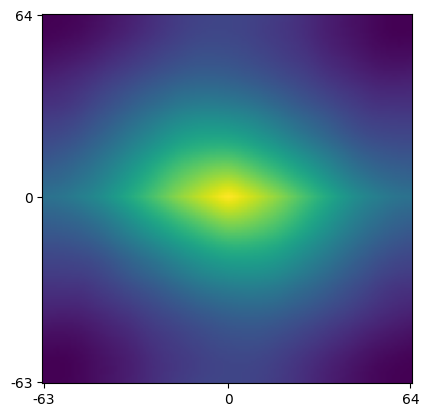

In [3]:
# calculate cross-correlation

def cross_correlation(frame1:np.ndarray, frame2:np.ndarray) -> np.ndarray:
	f1_fft = np.fft.fft2(frame1)
	f2_fft = np.fft.fft2(frame2)
	product = f1_fft * np.conj(f2_fft)
	crosscorr = np.fft.ifft2(product).real
	return crosscorr

def plt_correlation(correlation: np.ndarray):
	halfy, halfx = correlation.shape
	halfx *= 0.5
	halfy *= 0.5

	plt.imshow(np.fft.fftshift(correlation), origin="lower")
	plt.xticks([0, halfx, correlation.shape[1]-1], [-int(halfx-1), 0, int(halfx)])
	plt.yticks([0, halfy, correlation.shape[0]-1], [-int(halfy-1), 0, int(halfy)])

crosscorr = cross_correlation(subwindow, subwindow_shifted)
plt_correlation(crosscorr)

In [8]:
# create animation

import cv2
from fits_to_mp4 import get_frame_bgr
from matplotlib import cm

scale_factor = 4
video_writer = cv2.VideoWriter(
    "crosscor_anim.mp4",
    cv2.VideoWriter_fourcc(*"mp4v"),
    60,
    (int(img_size * scale_factor), int(img_size * scale_factor))
)

for i in range(img_size * 2):
	delta = i
	if delta > img_size:
		delta = img_size - (delta - img_size)
	
	window = data[xy[0]:xy[0]+img_size, xy[1]:xy[1]+img_size]
	window_shifted = data[xy[0]+delta:xy[0]+delta+img_size, xy[1]+delta:xy[1]+delta+img_size]

	crosscorr = cross_correlation(window, window_shifted)
	centered_crosscorr = np.fft.fftshift(crosscorr)

	data_min = np.min(centered_crosscorr)
	data_max = np.max(centered_crosscorr)
	data_range = (data_max - data_min)
	
	scaled_img = np.repeat(np.repeat(centered_crosscorr, scale_factor, axis=0), scale_factor, axis=1)

	frame = get_frame_bgr(
		scaled_img,
		video_writer,
		cm.get_cmap("viridis"),
		data_range, data_min,
	)

	cv2.putText(frame, f"Pixel Shift: {delta}", (5, 15), cv2.FONT_HERSHEY_COMPLEX, 0.5, (255,255,255), 1, cv2.LINE_AA)
	video_writer.write(frame)

video_writer.release()
	
	

/tmp/ipykernel_31541/3151331317.py:35: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cm.get_cmap("viridis"),
